In [3]:

def nth_term(a,d,n):
    return (a+(n-1)*d)

    
print(nth_term(2,3,5))


14


In [4]:
def sum_nth(a,d,n):
    return (n/2)*(2*a+(n-1)*d)

print(sum_nth(2,3,10))

155.0


In [5]:
a,d,n=2,3,10
s=sum(a+i*d for i in range(n))
print(s)

155


In [10]:

# check if a list is an Arithmetic Sequence
def is_arithmetic(nums):
    if len(nums) < 2:
        return True
    
    diff = nums[1] - nums[0]
    
    for i in range(1, len(nums) - 1):
        if nums[i+1] - nums[i] != diff:
            return False
    
    return True


print(is_arithmetic([5, 7, 9, 11]))  # True
print(is_arithmetic([1, 2, 4, 5]))   # False

True
False


Time series data

            Temperature
Timestamp              
2026-03-25           26
2026-03-26           30
2026-03-27           25
2026-03-28           22
2026-03-29           28
2026-03-30           33
2026-03-31           27
2026-04-01           27
2026-04-02           27
2026-04-03           23

Average Temperature: 26.8
Maximum Temperature: 33
Minimum Temperature: 22

Data with trend:

            Temperature  Trend
Timestamp                     
2026-03-25           26    NaN
2026-03-26           30    4.0
2026-03-27           25   -5.0
2026-03-28           22   -3.0
2026-03-29           28    6.0
2026-03-30           33    5.0
2026-03-31           27   -6.0
2026-04-01           27    0.0
2026-04-02           27    0.0
2026-04-03           23   -4.0


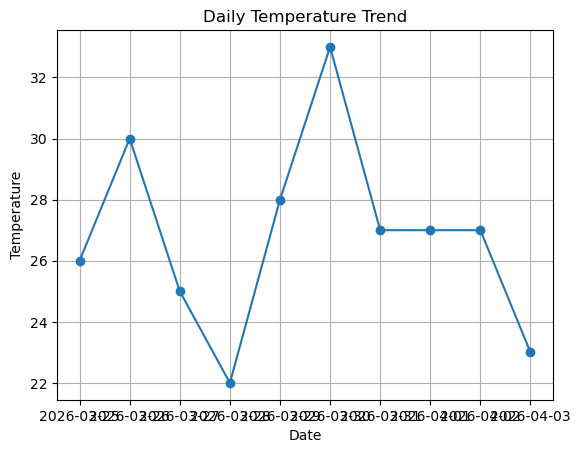


Predicted Temperature for 2026-04-04 : 26.8


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   # ✅ FIX ADDED

# create daily time index
time_index = pd.date_range(start="2026-03-25", periods=10, freq='D')

# simulate temperature data
temperature = np.random.randint(20, 35, size=10)

# create dataframe
df = pd.DataFrame({
    'Timestamp': time_index,
    'Temperature': temperature
})

# set index
df.set_index('Timestamp', inplace=True)

# display
print("Time series data\n")
print(df)

# stats
print("\nAverage Temperature:", df['Temperature'].mean())
print("Maximum Temperature:", df['Temperature'].max())
print("Minimum Temperature:", df['Temperature'].min())

# trend
df['Trend'] = df['Temperature'].diff()

print("\nData with trend:\n")
print(df)

# plot
plt.figure()
plt.plot(df.index, df['Temperature'], marker='o')
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("Daily Temperature Trend")
plt.grid()
plt.show()

# prediction
next_day = df.index[-1] + pd.Timedelta(days=1)
predicted_temp = df['Temperature'].mean()

print("\nPredicted Temperature for", next_day.date(), ":", predicted_temp)

In [2]:
import numpy as np
import pandas as pd

# data
hours = np.array([1, 2, 3, 5, 6, 8, 9, 10])

# Step 1: Feature scaling (Min-Max)
scaled = (hours - hours.min()) / (hours.max() - hours.min())

# Step 2: Create bins using Arithmetic Sequence
bins = np.linspace(hours.min(), hours.max(), 4)  # 4 bin edges

# Step 3: Assign bins (categorization)
categories = pd.cut(hours, bins=bins, labels=["Low", "Medium", "High"], include_lowest=True)

# display
df = pd.DataFrame({
    "Hours": hours,
    "Scaled": scaled,
    "Category": categories
})

print(df)

   Hours    Scaled Category
0      1  0.000000      Low
1      2  0.111111      Low
2      3  0.222222      Low
3      5  0.444444   Medium
4      6  0.555556   Medium
5      8  0.777778     High
6      9  0.888889     High
7     10  1.000000     High


In [4]:
from scipy.stats import gmean
#generate a GS
def generate_gp(a,r,n):
    return [a*(r**(i)) for i in range(n)]

print(gmean(generate_gp(2,3,5)))

17.999999999999996


In [5]:
#social media app user grow 20% daily
import numpy as np
#initial users
a=1000
r=1.2 #20% growth r=1+0.2=1.2
days=10
users=[a*(r**n) for n in range(days)]
print("users growth: \n",users)

#modify by ploting a graph
#growth is multiplicative(per-based)

#if val increases by same per-GS
#if val increases by same amount-AS

users growth: 
 [1000.0, 1200.0, 1440.0, 1727.9999999999998, 2073.6, 2488.3199999999993, 2985.9839999999995, 3583.180799999999, 4299.816959999998, 5159.780351999999]


Users growth:
 [1000.0, 1200.0, 1440.0, 1727.9999999999998, 2073.6, 2488.3199999999993, 2985.9839999999995, 3583.180799999999, 4299.816959999998, 5159.780351999999]


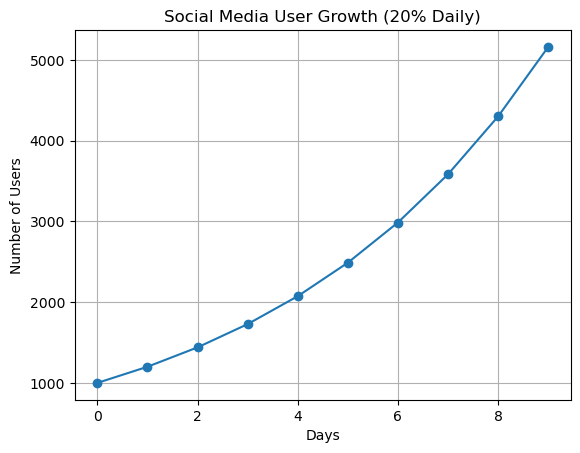

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# initial users
a = 1000
r = 1.2   # 20% growth
days = 10

# generate GP (user growth)
users = [a * (r ** n) for n in range(days)]

print("Users growth:\n", users)

# plot graph
plt.figure()
plt.plot(range(days), users, marker='o')
plt.xlabel("Days")
plt.ylabel("Number of Users")
plt.title("Social Media User Growth (20% Daily)")
plt.grid()
plt.show()

In [9]:
# a battery reduces 20% every hour

# initial battery %
a = 100

# remaining percentage after each hour (80%)
r = 0.8

hours = 5

print("Battery drain over time:\n")

for n in range(hours):
    battery = a * (r ** n)
    print(f"Hour {n}: {round(battery, 2)}%")

Battery drain over time:

Hour 0: 100.0%
Hour 1: 80.0%
Hour 2: 64.0%
Hour 3: 51.2%
Hour 4: 40.96%


In [10]:
a=20
d=5
n=10
days=[a+i*d for i in range(10)]
print("Daily usage:",days)

Daily usage: [20, 25, 30, 35, 40, 45, 50, 55, 60, 65]


In [ ]:
#ML training 10% decrease each epoch  GP 10ep=?
e1=0.01
r=0.9
e10=e1*(r**9)
print("Learning  rate at epoch 10:",e10)
epochs=[e1*(r**i) for i in range(10)]
print("For each epoch:",epochs)